# 03 BMRA

Run BMRA based on global responses derived from the pathway activity predictions.

In [1]:
import pandas as pd
import numpy as np
import os
import bmra

In [2]:
cell_line = 'BC3C_dec'

data_dir =f'.'
data_dir_1 = os.path.join(data_dir, f'00_outputs_2020_{cell_line}/')
data_dir_2 = os.path.join(data_dir, f'01_outputs_2020_{cell_line}/')

info_dir =f"."

out_dir = os.path.join(data_dir,f'02_outputs_2020_{cell_line}/')


os.makedirs(out_dir, exist_ok = True)

## Load data

### Global responses

Assembled from global responses calculated from predicted pathway activities, and DPD global responses.

In [3]:
def assemble_R_global(pathway_rglobal_file, dpd_rglobal_file):
    """
    Assemble full R_global matrix
    """
    R_global_modules_df = pd.read_csv(pathway_rglobal_file, index_col = 0)

    perts = R_global_modules_df.columns.tolist()

    R_global_DPD_df = pd.read_csv(dpd_rglobal_file, index_col=0).T

    # filter by perts list
    R_global_DPD_df = R_global_DPD_df[R_global_DPD_df.index.isin(perts)]

    # sort by perts list
    R_global_DPD_df["sort_col"] = R_global_DPD_df.index.map({val: i for i, val in enumerate(perts)})
    R_global_DPD_df = R_global_DPD_df.sort_values("sort_col")
    R_global_DPD_df = R_global_DPD_df.drop("sort_col", axis = 1)

    # transpose
    R_global_DPD_df = R_global_DPD_df.T

    R_global_df = pd.concat([R_global_modules_df, R_global_DPD_df])

    return R_global_df

In [4]:
R_global_df = assemble_R_global(
    pathway_rglobal_file = os.path.join(data_dir_2, "R_global_annotated.csv"),
    dpd_rglobal_file = os.path.join(data_dir_1, "R_global_DPDonly_annotated.csv"),
)

modules = R_global_df.index.tolist()
exp_ids = R_global_df.columns.tolist()

R_global = R_global_df.values
n_modules = R_global.shape[0]

print(R_global.shape)
display(R_global_df)

(13, 106)


,ASG002_BC3C_24H:A10,ASG002_BC3C_24H:A11,ASG002_BC3C_24H:A19,ASG002_BC3C_24H:A20,ASG002_BC3C_24H:A21,ASG002_BC3C_24H:B10,ASG002_BC3C_24H:B11,ASG002_BC3C_24H:B14,ASG002_BC3C_24H:B15,ASG002_BC3C_24H:C13,...,SMAD3_V11,SMAD3_V12,SMAD3_V13,SMAD3_V14,SMAD3_V15,SMAD3_V16,SMAD3_V17,SMAD3_V18,SMAD3_V19,SMAD3_V20
CDK1_2,-0.732390,-0.574169,0.050155,0.012087,0.083663,-0.269644,-0.071210,-0.419322,0.168162,0.000455,...,-0.392616,-0.371779,-0.341616,-0.356420,-0.331142,-0.345354,-0.338661,-0.366885,-0.367983,-0.393504
CDK4_6,0.004030,-0.089402,-0.280510,-0.119658,0.028711,-0.109703,-0.095605,-0.044628,-0.255945,0.009910,...,0.242901,0.237699,0.207865,0.187782,0.172492,0.183619,0.212328,0.202168,0.237499,0.206748
EGFR,0.603330,0.512815,0.220783,0.380757,0.550770,0.128326,-0.446151,0.263512,0.283021,-0.022212,...,-1.338967,-0.872734,-0.861788,-0.741935,-0.713491,-0.729167,-0.787042,-0.962566,-0.939140,-0.994961
Estrogen,-0.191659,-0.297802,-0.285529,-0.501957,-0.989677,-0.325297,-0.088943,-0.358269,-0.237886,-0.053961,...,-0.290892,-0.266312,-0.240691,-0.266860,-0.251275,-0.257787,-0.230941,-0.277576,-0.258940,-0.303853
FGFR,-0.117587,-0.197198,-0.100121,0.064252,-0.035630,-0.440261,-0.024733,-0.056993,-0.072518,-0.299410,...,-0.907491,-0.739510,-0.678187,-0.680680,-0.608604,-0.662346,-0.666099,-0.755526,-0.763380,-0.842649
PI3K,-1.938907,-1.866251,-1.679461,-1.422017,-0.626225,-0.173818,-0.007736,-0.480697,-1.360985,-0.234594,...,-0.131956,-0.076407,-0.032055,-0.067374,-0.041878,-0.083457,-0.055419,-0.085363,-0.087070,-0.165278
p53,-0.263693,-0.325991,-0.080932,-0.344558,0.028018,-1.805633,-1.718792,-0.118466,-0.069635,-1.552936,...,0.051077,0.031216,0.044455,0.047418,0.020214,0.047434,0.069707,0.028504,0.070372,0.034327
TOP2A,-0.292815,0.069931,-0.206117,-0.184430,-0.130647,0.020220,0.014743,-1.999184,-0.250836,-0.389917,...,0.153189,0.142490,0.133605,0.112587,0.101270,0.129074,0.139052,0.126773,0.151159,0.145054
Src,-1.059787,-1.997316,0.579319,-1.500732,0.615107,-1.377403,0.538403,0.453884,0.456147,0.498961,...,-0.116252,-0.146028,-0.090411,-0.119875,-0.048745,-0.110704,-0.091114,-0.104768,-0.147164,-0.157167
SMAD3,0.005522,-0.157591,0.044225,-0.404625,0.063312,0.086322,0.034546,0.172641,0.172731,0.059999,...,-1.378356,-1.228306,-1.156636,-1.215284,-1.149212,-1.171070,-1.142051,-1.264353,-1.236354,-1.342972


In [5]:
print(R_global_df.values.min())
print(R_global_df.values.max())

-2.0004641290341234
1.26621642829064


### Perturbation matrix

In [6]:
inhib_conc_df = pd.read_csv(os.path.join(data_dir_1, "inhib_conc_annotated.csv"), index_col = 0)
#LFC_PLCg = pd.read_csv(os.path.join(info_dir,"PLCg_Data_log_2020.csv"),index_col=0)
#inhib_conc = inhib_conc_df.drop(columns=LFC_PLCg.index).values
inhib_conc = inhib_conc_df.values

n_DPDs = R_global.shape[0] - inhib_conc.shape[0]

pert_modules = np.where(inhib_conc != 0, 1, 0)
pert_DPD = np.zeros((n_DPDs, len(exp_ids)))

pert = np.vstack([pert_modules, pert_DPD])

print(pert.shape)
print(pert)

(13, 106)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Networks

In [7]:
# empty prior
#G_prior = np.zeros((n_modules, n_modules))
G_prior_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020.xlsx"), sheet_name = "prior_net_work", index_col = 0)

G_prior = G_prior_df.values
G_prior_df

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno
CDK1_2,0,0,0,0,0,0,0,0,0,0,0,0,0
CDK4_6,0,0,0,0,0,0,0,0,0,0,0,0,0
EGFR,0,0,0,0,0,0,0,0,0,0,0,0,0
Estrogen,0,0,0,0,0,0,0,0,0,0,0,0,0
FGFR,0,0,0,0,0,0,0,0,0,0,0,0,0
PI3K,0,0,0,0,0,0,0,0,0,0,0,0,0
p53,0,0,0,0,0,0,0,0,0,0,0,0,0
TOP2A,0,0,0,0,0,0,0,0,0,0,0,0,0
Src,0,0,0,0,0,0,0,0,0,0,0,0,0
SMAD3,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
#G_prior_r_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020.xlsx"), sheet_name = "prior_r", index_col = 0)

#G_prior_r = G_prior_r_df.values
#G_prior_r_df

In [9]:
G_not = np.eye(n_modules)
G_not[:, n_modules - n_DPDs :] = 1

G_not

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.]])

## Run BMRA

In [10]:
n_gibbs = 200_000
n_window = 5_000

mode = "all"
n_iterations = 1

In [11]:
A_mean, A_sd, r_mean, r_sd = bmra.run_bmra(R_global,
            pert,
            G_prior,
            G_not,
            #r_prior = G_prior_r,
            n_gibbs = n_gibbs,
            n_window = n_window,
            mode = mode,
            n_iterations = n_iterations,
        )

A_mean_df = pd.DataFrame(A_mean, index = modules, columns = modules)
A_sd_df = pd.DataFrame(A_sd, index = modules, columns = modules)
r_mean_df = pd.DataFrame(r_mean, index = modules, columns = modules)
r_sd_df = pd.DataFrame(r_sd, index = modules, columns = modules)

display(A_mean_df)
display(A_sd_df)
display(r_mean_df)
display(r_sd_df)

A_mean_df.to_csv(os.path.join(out_dir, "A_mean.csv"))
A_sd_df.to_csv(os.path.join(out_dir, "A_sd.csv"))
r_mean_df.to_csv(os.path.join(out_dir, "r_mean.csv"))
r_sd_df.to_csv(os.path.join(out_dir, "r_sd.csv"))

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno
CDK1_2,0.0,0.001322,1.000000,0.00000,1.000000,1.000000,0.000317,0.000000,0.430873,0.000000,0.0,0.0,0.0
CDK4_6,0.0,0.000000,0.000000,1.00000,0.033584,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.0
EGFR,0.0,0.000000,0.000000,0.00000,1.000000,1.000000,0.000176,0.000000,0.431673,1.000000,0.0,0.0,0.0
Estrogen,0.0,0.010386,0.000000,0.00000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0
FGFR,0.0,0.000181,1.000000,0.00000,0.000000,1.000000,0.178873,0.000000,0.000000,1.000000,0.0,0.0,0.0
PI3K,1.0,0.000000,0.591812,1.00000,0.000000,0.000000,0.005158,1.000000,0.968937,0.022358,0.0,0.0,0.0
p53,0.0,0.000000,1.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.111800,0.0,0.0,0.0
TOP2A,0.0,0.000000,1.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.0,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.0,0.000000,1.000000,0.00000,0.000000,0.111438,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno
CDK1_2,0.000000e+00,0.036331,1.110223e-16,0.000000e+00,1.110223e-16,1.110223e-16,1.780968e-02,0.000000e+00,4.951984e-01,0.000000e+00,0.0,0.0,0.0
CDK4_6,0.000000e+00,0.000000,0.000000e+00,6.661338e-16,1.801548e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.661338e-16,0.0,0.0,0.0
EGFR,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,4.440892e-16,4.440892e-16,1.324807e-02,0.000000e+00,4.953094e-01,4.440892e-16,0.0,0.0,0.0
Estrogen,0.000000e+00,0.101379,0.000000e+00,0.000000e+00,4.440892e-16,4.440892e-16,0.000000e+00,0.000000e+00,4.440892e-16,0.000000e+00,0.0,0.0,0.0
FGFR,0.000000e+00,0.013443,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.832463e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
PI3K,1.332268e-15,0.000000,4.914984e-01,1.332268e-15,0.000000e+00,0.000000e+00,7.163350e-02,1.332268e-15,1.734887e-01,1.478444e-01,0.0,0.0,0.0
p53,0.000000e+00,0.000000,1.665335e-15,0.000000e+00,0.000000e+00,1.665335e-15,0.000000e+00,0.000000e+00,0.000000e+00,3.151206e-01,0.0,0.0,0.0
TOP2A,0.000000e+00,0.000000,1.776357e-15,0.000000e+00,0.000000e+00,1.776357e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
Src,0.000000e+00,0.000000,0.000000e+00,1.554312e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
SMAD3,0.000000e+00,0.000000,2.220446e-16,0.000000e+00,0.000000e+00,3.146734e-01,0.000000e+00,0.000000e+00,2.220446e-16,0.000000e+00,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno
CDK1_2,0.000000,0.000168,0.168510,0.000000,0.211075,0.157991,0.000010,0.000000,0.026999,0.000000,0.0,0.0,0.0
CDK4_6,0.000000,0.000000,0.000000,0.149190,0.002743,0.000000,0.000000,0.000000,0.000000,-0.157992,0.0,0.0,0.0
EGFR,0.000000,0.000000,0.000000,0.000000,0.237728,-0.235472,0.000012,0.000000,-0.034703,0.518360,0.0,0.0,0.0
Estrogen,0.000000,0.001686,0.000000,0.000000,0.257395,0.224107,0.000000,0.000000,0.076155,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.000034,0.330606,0.000000,0.000000,0.158529,0.018136,0.000000,0.000000,0.235273,0.0,0.0,0.0
PI3K,0.320763,0.000000,-0.087939,0.342418,0.000000,0.000000,0.000371,0.566712,-0.125902,0.003282,0.0,0.0,0.0
p53,0.000000,0.000000,0.141646,0.000000,0.000000,0.205927,0.000000,0.000000,0.000000,-0.020291,0.0,0.0,0.0
TOP2A,0.000000,0.000000,-0.150049,0.000000,0.000000,0.206312,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.000000,0.000000,0.577289,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.000000,0.320595,0.000000,0.000000,0.009198,0.000000,0.000000,0.100306,0.000000,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno
CDK1_2,0.00000,0.004879,0.027132,0.000000,0.034851,0.023919,0.000623,0.000000,0.033852,0.000000,0.0,0.0,0.0
CDK4_6,0.00000,0.000000,0.000000,0.008677,0.014859,0.000000,0.000000,0.000000,0.000000,0.009279,0.0,0.0,0.0
EGFR,0.00000,0.000000,0.000000,0.000000,0.039224,0.019841,0.000891,0.000000,0.042586,0.030623,0.0,0.0,0.0
Estrogen,0.00000,0.016779,0.000000,0.000000,0.030532,0.023272,0.000000,0.000000,0.020266,0.000000,0.0,0.0,0.0
FGFR,0.00000,0.002554,0.027973,0.000000,0.000000,0.020073,0.040373,0.000000,0.000000,0.029180,0.0,0.0,0.0
PI3K,0.05861,0.000000,0.080047,0.057107,0.000000,0.000000,0.005625,0.071952,0.037965,0.022912,0.0,0.0,0.0
p53,0.00000,0.000000,0.049865,0.000000,0.000000,0.031221,0.000000,0.000000,0.000000,0.059660,0.0,0.0,0.0
TOP2A,0.00000,0.000000,0.006975,0.000000,0.000000,0.008117,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.00000,0.000000,0.000000,0.005289,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.00000,0.000000,0.018398,0.000000,0.000000,0.026815,0.000000,0.000000,0.010440,0.000000,0.0,0.0,0.0


In [12]:
np.fill_diagonal(r_mean_df.values,-1)
rm_minus_inv = pd.DataFrame(np.linalg.pinv(r_mean_df),index=r_mean_df.index,columns=r_mean_df.columns)*(-1)
rm_minus_inv.to_csv(os.path.join(out_dir, 'r_minv.csv'))
display(rm_minus_inv)

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno
CDK1_2,1.058211,0.000318,0.334475,0.076619,0.322598,0.181478,0.005933,0.102846,0.024996,0.249702,1.695414e-16,-4.457723e-16,3.765116e-16
CDK4_6,0.020643,1.000283,-0.051576,0.165022,0.037316,0.064356,0.000700,0.036471,-0.010822,-0.175795,-6.209296e-16,1.115957e-15,-1.385738e-15
EGFR,-0.112499,-0.000148,1.388577,-0.082322,0.285169,-0.350725,0.005057,-0.198760,0.065468,0.785645,3.935873e-16,-3.702528e-16,4.381681e-16
Estrogen,0.110738,0.001972,0.121998,1.151789,0.348846,0.345232,0.006457,0.195647,0.057650,0.146004,-1.361597e-16,-2.259487e-16,-6.849389e-16
FGFR,0.027928,0.000124,0.550539,0.047151,1.148910,0.087068,0.020876,0.049342,0.030001,0.555528,-8.488032e-17,-2.595425e-16,1.136448e-16
PI3K,0.440172,0.000747,-0.111485,0.395960,0.168326,1.372269,0.003565,0.777682,-0.128256,-0.013873,-5.981600e-16,-1.077926e-16,-6.553592e-16
p53,0.075228,0.000131,0.164574,0.068986,0.072760,0.234528,1.001409,0.132910,-0.019643,0.082856,3.940868e-16,-6.810836e-17,-4.696214e-16
TOP2A,0.107693,0.000176,-0.231356,0.094044,-0.008062,0.335741,-0.000023,1.190269,-0.036284,-0.120748,-5.390698e-16,1.131251e-16,-3.988297e-16
Src,0.063928,0.001138,0.070428,0.664914,0.201385,0.199299,0.003728,0.112945,1.033281,0.084286,1.513206e-16,-3.091141e-16,-5.327696e-16
SMAD3,-0.025606,0.000074,0.451209,0.043945,0.113172,-0.079828,0.002028,-0.045239,0.123454,1.260200,4.079772e-16,-6.400721e-16,-1.031847e-17


In [13]:
con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in r_mean_df.index:
    for con_from in r_mean_df.columns:
        if ((r_mean_df.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,r_mean_df.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net.txt'),sep='\t',index=False)
display(con_mat)

,From,To,Strength
0,CDK4_6,CDK1_2,0.000168
1,EGFR,CDK1_2,0.168510
2,FGFR,CDK1_2,0.211075
3,PI3K,CDK1_2,0.157991
4,p53,CDK1_2,0.000010
5,Src,CDK1_2,0.026999
6,Estrogen,CDK4_6,0.149190
7,FGFR,CDK4_6,0.002743
8,SMAD3,CDK4_6,-0.157992
9,FGFR,EGFR,0.237728


In [14]:
# now the same but with filtered matrices
# threshold value
Athr = 0.5

rm_filt = r_mean_df[np.abs(A_mean_df) > Athr].fillna(0).copy()
np.fill_diagonal(rm_filt.values,-1)
rm_filt.to_csv(os.path.join(out_dir, 'r_mean_filt.csv'))
display(rm_filt)

rm_filt_minus_inv = pd.DataFrame(np.linalg.pinv(rm_filt),index=rm_filt.index,columns=rm_filt.columns)*(-1)
rm_filt_minus_inv.to_csv(os.path.join(out_dir, 'r_minv_filt.csv'))
display(rm_minus_inv)

con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in rm_filt.index:
    for con_from in rm_filt.columns:
        if ((rm_filt.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,rm_filt.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net_filt.txt'),sep='\t',index=False)
#display(con_mat)


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno
CDK1_2,-1.000000,0.0,0.168510,0.000000,0.211075,0.157991,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
CDK4_6,0.000000,-1.0,0.000000,0.149190,0.000000,0.000000,0.000000,0.000000,0.000000,-0.157992,0.0,0.0,0.0
EGFR,0.000000,0.0,-1.000000,0.000000,0.237728,-0.235472,0.000000,0.000000,0.000000,0.518360,0.0,0.0,0.0
Estrogen,0.000000,0.0,0.000000,-1.000000,0.257395,0.224107,0.000000,0.000000,0.076155,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.0,0.330606,0.000000,-1.000000,0.158529,0.000000,0.000000,0.000000,0.235273,0.0,0.0,0.0
PI3K,0.320763,0.0,-0.087939,0.342418,0.000000,-1.000000,0.000000,0.566712,-0.125902,0.000000,0.0,0.0,0.0
p53,0.000000,0.0,0.141646,0.000000,0.000000,0.205927,-1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.000000,0.0,-0.150049,0.000000,0.000000,0.206312,0.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.0,0.000000,0.577289,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.0,0.320595,0.000000,0.000000,0.000000,0.000000,0.000000,0.100306,-1.000000,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno
CDK1_2,1.058211,0.000318,0.334475,0.076619,0.322598,0.181478,0.005933,0.102846,0.024996,0.249702,1.695414e-16,-4.457723e-16,3.765116e-16
CDK4_6,0.020643,1.000283,-0.051576,0.165022,0.037316,0.064356,0.000700,0.036471,-0.010822,-0.175795,-6.209296e-16,1.115957e-15,-1.385738e-15
EGFR,-0.112499,-0.000148,1.388577,-0.082322,0.285169,-0.350725,0.005057,-0.198760,0.065468,0.785645,3.935873e-16,-3.702528e-16,4.381681e-16
Estrogen,0.110738,0.001972,0.121998,1.151789,0.348846,0.345232,0.006457,0.195647,0.057650,0.146004,-1.361597e-16,-2.259487e-16,-6.849389e-16
FGFR,0.027928,0.000124,0.550539,0.047151,1.148910,0.087068,0.020876,0.049342,0.030001,0.555528,-8.488032e-17,-2.595425e-16,1.136448e-16
PI3K,0.440172,0.000747,-0.111485,0.395960,0.168326,1.372269,0.003565,0.777682,-0.128256,-0.013873,-5.981600e-16,-1.077926e-16,-6.553592e-16
p53,0.075228,0.000131,0.164574,0.068986,0.072760,0.234528,1.001409,0.132910,-0.019643,0.082856,3.940868e-16,-6.810836e-17,-4.696214e-16
TOP2A,0.107693,0.000176,-0.231356,0.094044,-0.008062,0.335741,-0.000023,1.190269,-0.036284,-0.120748,-5.390698e-16,1.131251e-16,-3.988297e-16
Src,0.063928,0.001138,0.070428,0.664914,0.201385,0.199299,0.003728,0.112945,1.033281,0.084286,1.513206e-16,-3.091141e-16,-5.327696e-16
SMAD3,-0.025606,0.000074,0.451209,0.043945,0.113172,-0.079828,0.002028,-0.045239,0.123454,1.260200,4.079772e-16,-6.400721e-16,-1.031847e-17


In [15]:
# number of zero elements in the matrix
display(len(rm_filt.index)*len(rm_filt.columns) - rm_filt.astype(bool).sum().sum())

np.int64(120)

In [16]:
# number of non-zero elements in the matrix
display(rm_filt.astype(bool).sum().sum() - len(modules))

np.int64(36)

### Visualization

In [19]:
df_subset=rm_filt_minus_inv[['Androgen', 'CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'p53','PI3K',  'TOP2A','Src','SMAD3']]
df_subset = df_subset.loc[['blca_basal_luminal',	'blca_oncogenesis',	'blca_survival']]

In [20]:
t_df_subset=df_subset.T
df_subset.reset_index(inplace=True)

Text(0.5, 1.0, 'Predicted global signaling pathway responses of BC3C_dec cell line (augmented matrix integrated)')

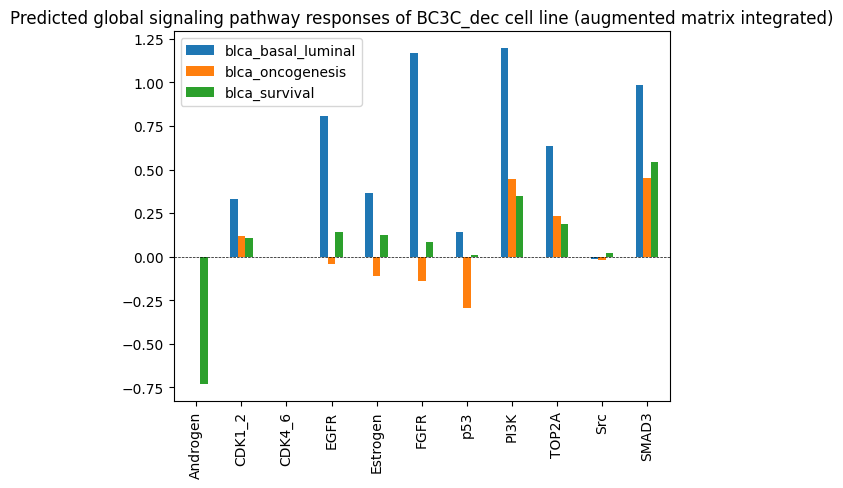

In [21]:
import matplotlib.pyplot as plt
t_df_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted global signaling pathway responses of {cell_line} cell line (augmented matrix integrated)")

In [23]:
display(rm_filt)
rm_subset=rm_filt[['Androgen','CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'PI3K', 'p53', 'TOP2A','Src','TGFBR/SMAD']]

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFBR/SMAD,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,-1.0,0.000000,0.0,-0.036271,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
CDK1_2,0.0,-1.000000,0.0,0.148730,0.000000,0.191798,0.252971,0.000000,0.000000,0.089251,0.000000,0.0,0.0,0.0
CDK4_6,0.0,0.000000,-1.0,0.000000,0.130940,0.000000,0.000000,0.000000,0.000000,0.000000,-0.155171,0.0,0.0,0.0
EGFR,0.0,0.000000,0.0,-1.000000,0.000000,0.333090,-0.297475,0.000000,0.000000,0.000000,0.547341,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.0,0.000000,-1.000000,0.263969,0.143495,0.000000,0.000000,0.085032,0.000000,0.0,0.0,0.0
FGFR,0.0,0.000000,0.0,0.430344,0.133234,-1.000000,0.148521,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
PI3K,0.0,0.355449,0.0,-0.268547,0.000000,0.000000,-1.000000,0.000000,0.597642,0.000000,0.282728,0.0,0.0,0.0
p53,0.0,0.000000,0.0,0.140947,0.000000,0.000000,0.081025,-1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.0,-0.133274,0.000000,0.000000,0.166169,0.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.0,0.331858,0.0,0.000000,0.528373,0.000000,-0.259721,0.000000,0.000000,-1.000000,0.000000,0.0,0.0,0.0


In [24]:
rm_subset=rm_subset.loc[['blca_basal_luminal',	'blca_oncogenesis',	'blca_survival']]
rm_subset=rm_subset.T
display(rm_subset)

,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000,0.000000
CDK1_2,8.016145,0.000000,0.000000
CDK4_6,0.000000,0.000000,0.000000
EGFR,0.000000,0.000000,0.000000
Estrogen,0.000000,-0.287235,0.000000
FGFR,29.906385,0.000000,0.000000
PI3K,18.757218,0.384438,4.383326
p53,0.000000,-0.301065,0.000000
TOP2A,0.000000,0.000000,0.000000
Src,0.000000,0.000000,0.000000


Text(0.5, 1.0, 'Predicted local signaling pathway responses of BC3C_dec cell line (augmented matrix integrated)')

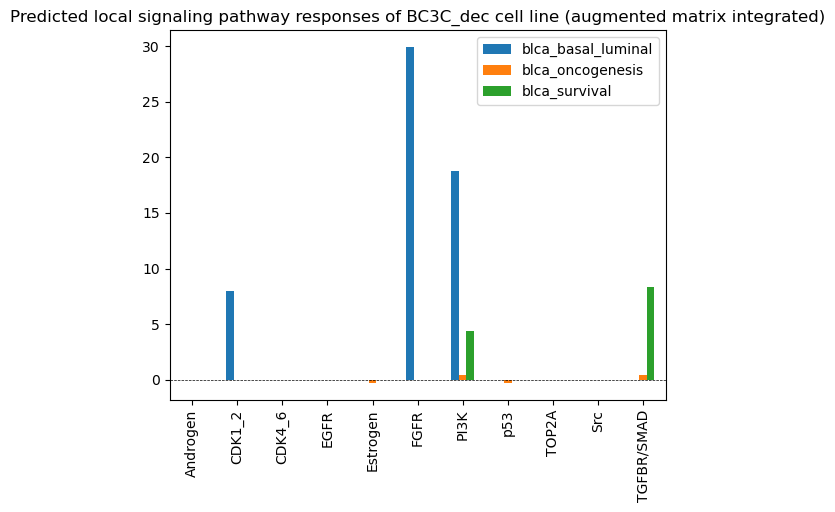

In [25]:
rm_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted local signaling pathway responses of {cell_line} cell line (augmented matrix integrated)")